# 2.4 — Обучение DPI-EVT

**Папка 2 «Обучение», подноутбук 4.** DPI-EVT — гибрид: энкодер DPI-Flow выводит латент θ, из
которого строится **развязанная (decoupled)** граница CRR и траектория PPR(N), а число циклов
до разжижения берётся **из самой кривой PPR** (`nliq_from_curve=True`). Это делает модель
согласованным источником PPR, CRR, риска и N_liq без утверждений о лидерстве внутри training notebook.
Актуальные места моделей определяются только в `results/tables/*.csv`, которые пересчитывает серия `3_*`.

Раньше DPI-EVT обучался отдельным скриптом `run_dpievt.py` и не имел своего ноутбука — из-за
чего при чистой папке `models/` он терял веса и выпадал из оценки. Этот ноутбук **штатно**
обучает, калибрует и сохраняет DPI-EVT, повторяя ту же процедуру:

* фиксированный seed, **косинусный планировщик LR** (`scheduler="cosine"`) — ключ к качеству;
* развязанная CRR + N_liq из кривой, без traj-residual и без внутренней калибровки θ;
* пост-hoc калибровка ширины интервалов (`fit_interval_scale`).

> Важно: качество DPI-EVT чувствительно к косинусному расписанию LR — обычный прогон
> `train_model` без планировщика заметно его ухудшает.


## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch
from liquefaction_ai import (get_default_config, load_population_artifact,
                             prepare_benchmark_dataset, train_model, set_global_seed)
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, fit_interval_scale
from liquefaction_ai.models import DPIEvtNet

config = get_default_config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
population, config = load_population_artifact(DATA_DIR)
benchmark = prepare_benchmark_dataset(population, config, device)
train, val, test = benchmark["train"], benchmark["val"], benchmark["test"]
static_dim = train["static"].shape[1]; prefix_dim = train["prefix_summary"].shape[1]
seq_dim = train["seq_in"].shape[-1]
print("Источник:", DATA_DIR.name, "| train/val/test:",
      train["static"].shape[0], val["static"].shape[0], test["static"].shape[0],
      "| static_dim:", static_dim)

Источник: dataset | train/val/test: 675 140 181 | static_dim: 34


## Шаг 1. Конфигурация и сборка модели

Параметры DPI-EVT соответствуют рабочей конфигурации: развязанная CRR, N_liq из кривой,
вероятностная голова и flow, без traj-residual и без внутренней калибровки θ.

**Порог разжижения.** `liq_threshold` берётся из общего конфига (`config.liq_threshold`) и
сохраняется в `models/dpi_evt/hyperparams.json`, поэтому training notebook, модельный артефакт
и оценка используют один и тот же порог. В текущем артефакте это `0.95`; итоговые значения
N_liq, CRR, Brier и CRPS не фиксируются в тексте ноутбука, а читаются из таблиц серии `3_*`.


In [2]:
MC_SOTA = False   # #3: включить MC-mixture обучение неопределённости DPI-EVT
SELECTION_METRIC = "Traj_RMSE"   # метрика отбора лучшей комбинации
fixed = dict(
    static_dim=static_dim, prefix_dim=prefix_dim, seq_dim=seq_dim,
    seq_len=config.seq_len, prefix_len=config.prefix_len,
    max_cycle_reference=config.max_cycle_reference,
    probabilistic=True, use_flow=False,                 # поток дестабилизирует EVT-движок
    nliq_from_curve=True, liq_threshold=config.liq_threshold,
    use_traj_residual=False,
    # MC-микстура (#3): калибрует разброс гауссова постериора под предиктивную ошибку
    # (mixture-NLL + energy-CRPS). MC_SOTA=False → прежнее поведение. use_flow остаётся False.
    **(dict(mc_train_samples=4, mc_crps_weight=0.3) if (globals().get('MC_SOTA', False)) else dict()),
)
# Разнообразный грид DPI-EVT: ёмкость энкодера × способ построения отчётной CRR × глубина
# дифференцируемой калибровки θ по префиксу. crr_mode — ключевая ось проекта (decoupled снимает
# компромисс «траектория↔CRR», hybrid/damage — альтернативы).
grid = {"hidden_dim": [128, 160, 192],
        "crr_mode": ["decoupled", "hybrid", "damage"],
        "calibration_steps": [0, 1]}
res, best = grid_search(lambda p: DPIEvtNet(**fixed, **p), grid, train, val,
                        config, device, search_epochs=config.grid_search_epochs,
                        score_metric=SELECTION_METRIC)
print("Selection metric:", SELECTION_METRIC, "| best:", best)
display(res.head(8))

model_kwargs = {**fixed, **best}
EPOCHS = config.publication_physics_epochs
set_global_seed(config.seed)          # единый сид проекта (детерминированная инициализация)
model = DPIEvtNet(**model_kwargs).to(device)
n_params = sum(p.numel() for p in model.parameters())
print("DPI-EVT параметров:", f"{n_params:,}", "| эпох:", EPOCHS)

Selection metric: Traj_RMSE | best: {'hidden_dim': 160, 'crr_mode': 'decoupled', 'calibration_steps': 1}


,hidden_dim,crr_mode,calibration_steps,val_loss,N_liq_MAE,N_liq_RMSE,N_liq_logMAE,N_liq_logRMSE,N_liq_n_observed,N_liq_logMAE_liq,...,Interval_Width_90,Coverage_95,Interval_Width_95,Calibration_Error,Traj_NLL,Traj_CRPS,CRR_RMSE,N_CRR_test,N_CRR_objects,Produces_CRR
0,160,decoupled,1,-2.184062,21.583061,35.005390,0.142630,0.211512,101.0,0.197337,...,0.165632,0.932030,0.197361,0.016888,-1.538874,0.030367,0.133772,73.0,1.0,1.0
1,160,hybrid,1,-2.306874,25.161467,39.365868,0.169585,0.235230,101.0,0.234632,...,0.176049,0.913408,0.209773,0.021579,-1.446025,0.032196,0.131205,73.0,1.0,1.0
2,160,hybrid,0,-2.310910,26.413311,40.242611,0.180314,0.246654,101.0,0.249476,...,0.179250,0.903033,0.213587,0.035945,-1.400124,0.033187,0.129873,73.0,1.0,1.0
3,128,damage,0,-2.205418,29.899931,47.428150,0.190730,0.261526,101.0,0.263887,...,0.172435,0.912743,0.205466,0.035501,-1.495823,0.034054,0.100933,73.0,1.0,1.0
4,128,damage,1,-2.209442,30.021603,47.550365,0.191592,0.262356,101.0,0.265079,...,0.172260,0.912610,0.205259,0.035856,-1.494628,0.034093,0.100913,73.0,1.0,1.0
5,128,hybrid,0,-2.167193,29.158638,45.699158,0.186310,0.256249,101.0,0.257771,...,0.152592,0.896249,0.181823,0.073898,-1.454097,0.034018,0.123103,73.0,1.0,1.0
6,128,hybrid,1,-2.174318,28.422634,44.506245,0.182627,0.251982,101.0,0.252676,...,0.153828,0.900771,0.183295,0.066582,-1.473401,0.033990,0.123272,73.0,1.0,1.0
7,192,damage,1,-2.071083,33.473747,53.254368,0.204800,0.281052,101.0,0.283354,...,0.180805,0.880287,0.215441,0.077667,-1.369389,0.037259,0.100678,73.0,1.0,1.0


DPI-EVT параметров: 315,364 | эпох: 200


## Шаг 2. Обучение с косинусным планировщиком LR

Это ключевой момент: косинусное расписание шага обучения существенно улучшает сходимость
DPI-EVT по сравнению с обычным прогоном.

In [3]:
model, history = train_model(model, train, val, epochs=EPOCHS, model_name="DPI-EVT",
                             config=config, device=device, track_metrics=True,
                             scheduler="cosine", ema_decay=0.0)
display(history)

[DPI-EVT] эпоха 01 | обучение=2.7437 | валидация=-0.1683 | val_AUROC=0.810 | val_RMSE=0.2487 | stale=0/25
[DPI-EVT] эпоха 02 | обучение=-0.0696 | валидация=-0.8960 | val_AUROC=0.768 | val_RMSE=0.2395 | stale=0/25
[DPI-EVT] эпоха 03 | обучение=-0.8008 | валидация=-1.1047 | val_AUROC=0.778 | val_RMSE=0.2313 | stale=0/25
[DPI-EVT] эпоха 04 | обучение=-1.1099 | валидация=-1.3366 | val_AUROC=0.835 | val_RMSE=0.1808 | stale=0/25
[DPI-EVT] эпоха 05 | обучение=-1.2246 | валидация=-1.5382 | val_AUROC=0.857 | val_RMSE=0.2259 | stale=0/25
[DPI-EVT] эпоха 06 | обучение=-1.3892 | валидация=-1.8107 | val_AUROC=0.870 | val_RMSE=0.1104 | stale=0/25
[DPI-EVT] эпоха 07 | обучение=-1.5859 | валидация=-2.0494 | val_AUROC=0.886 | val_RMSE=0.0813 | stale=0/25
[DPI-EVT] эпоха 08 | обучение=-1.7703 | валидация=-1.9453 | val_AUROC=0.894 | val_RMSE=0.1299 | stale=1/25
[DPI-EVT] эпоха 09 | обучение=-1.5198 | валидация=-1.5694 | val_AUROC=0.899 | val_RMSE=0.1589 | stale=2/25
[DPI-EVT] эпоха 10 | обучение=-0.4658 

,epoch,train_loss,val_loss,val_auroc,val_brier,val_traj_rmse,best_val_loss,epochs_without_improvement,best_epoch
0,1,2.743740,-0.168321,0.810059,0.227017,0.248669,-0.168321,0,1
1,2,-0.069585,-0.896021,0.767941,0.275252,0.239517,-0.896021,0,2
2,3,-0.800800,-1.104748,0.778062,0.294055,0.231348,-1.104748,0,3
3,4,-1.109882,-1.336642,0.835208,0.311048,0.180751,-1.336642,0,4
4,5,-1.224602,-1.538159,0.856676,0.281914,0.225924,-1.538159,0,5
5,6,-1.389223,-1.810678,0.869965,0.278483,0.110415,-1.810678,0,6
6,7,-1.585909,-2.049423,0.886117,0.278435,0.081274,-2.049423,0,7
7,8,-1.770322,-1.945258,0.893887,0.278366,0.129885,-2.049423,1,7
8,9,-1.519803,-1.569450,0.898998,0.278305,0.158862,-2.049423,2,7
9,10,-0.465810,0.298410,0.902883,0.278259,0.192812,-2.049423,3,7


## Шаг 3. Кривые обучения

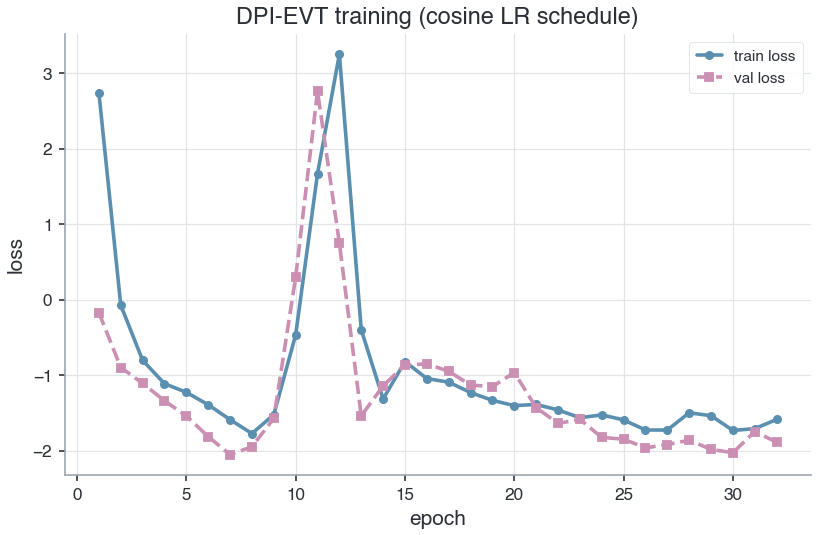

In [4]:
from liquefaction_ai.viz import new_figure, save_figure, QUALITATIVE, GRID
figw, fig = new_figure((7.4, 4.4)); ax = fig.add_subplot(111)
ax.plot(history["epoch"], history["train_loss"], "-o", color=QUALITATIVE[0], label="train loss", markersize=4)
ax.plot(history["epoch"], history["val_loss"], "--s", color="#CB8FB3", label="val loss", markersize=4)
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
if "val_AUROC" in history.columns:
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(history["epoch"], history["val_AUROC"], "-^", color="#7FB286", label="val AUROC", markersize=4)
    ax2.set_ylabel("val AUROC"); ax2.set_ylim(0.9, 1.0)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8.5, loc="center right")
else:
    ax.legend(fontsize=8.5)
ax.set_title("DPI-EVT training (cosine LR schedule)")
save_figure(figw, "2_4_dpi_evt_training", SAVE_FIGS)
figw

## Шаг 4. Калибровка интервалов и оценка на тесте

`fit_interval_scale` подбирает масштаб ширины интервалов по валидации (целевое покрытие 90 %).
Затем считаем полный набор метрик на тестовой выборке.

In [5]:
calib_scale = fit_interval_scale(model, val, config, device, level=0.90)
metrics, _ = compute_metrics("DPI-EVT", collect_outputs(model, test, config, device), test, config)
keys = [("PPR Traj_RMSE", "Traj_RMSE"), ("Traj CRPS", "Traj_CRPS"), ("Calibration err", "Calibration_Error"),
        ("AUROC", "AUROC"), ("Brier", "Brier"), ("Physics violation", "Physics_Violation_Rate"),
        ("N_liq logMAE", "N_liq_logMAE"), ("N_liq MAE", "N_liq_MAE"), ("CRR RMSE", "CRR_RMSE")]
display(pd.DataFrame({"Metric": [k for k, _ in keys],
                      "DPI-EVT": [round(float(metrics[v]), 4) if metrics[v] == metrics[v] else None for _, v in keys]}))
print("calib_scale:", round(float(calib_scale), 3))

,Metric,DPI-EVT
0,PPR Traj_RMSE,0.1307
1,Traj CRPS,0.0635
2,Calibration err,0.0907
3,AUROC,1.0000
4,Brier,0.0072
5,Physics violation,0.0000
6,N_liq logMAE,0.0598
7,N_liq MAE,18.6108
8,CRR RMSE,0.1208


calib_scale: 0.5


## Шаг 5. Сохранение модели

Сохраняем веса, гиперпараметры (с `calib_scale`) и историю — в том же формате, что и остальные
модели, поэтому ноутбуки оценки серии 3 подхватывают DPI-EVT автоматически.

In [6]:
hp = {"model_type": "DPIEvtNet", "display_name": "DPI-EVT", "model_kwargs": model_kwargs,
      "search": {"grid": grid, "score_metric": SELECTION_METRIC, "best": best}}
write_hyperparams(MODELS_DIR, "dpi_evt", hp)
save_trained_model(model, MODELS_DIR, "dpi_evt", {**hp, "epochs": len(history), "calib_scale": float(calib_scale)}, history)
print("DPI-EVT сохранён в", MODELS_DIR / "dpi_evt")

DPI-EVT сохранён в /Users/nikita/Desktop/projects/liquefaction-ai/models/dpi_evt


## Итог

DPI-EVT обучен штатно (косинусный LR, развязанная CRR, N_liq из кривой), откалиброван и
сохранён в `models/dpi_evt`. Теперь он воспроизводимо входит в пайплайн: после `2_1`–`2_3`
запустите этот ноутбук — и серия `3_*` оценит полный набор моделей, включая DPI-EVT, по
единому grouped/site-heldout протоколу.

Запускать после смены датасета (ноутбук `1_0`) или при пустой папке `models/`.
